# SI - Figure 4 multistart fit sensitivity

The Figure 4 overlap fit has several phase-equivalent minima. This notebook sweeps 20 initial reference-angle guesses from -6 to 6 degrees, groups the converged solutions into five parameter branches, and shows that the direct-overlap fits coincide while their inferred cross-talk differs.

In [1]:
from pathlib import Path

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np


def find_repository_root():
    for candidate in (Path.cwd(), *Path.cwd().parents):
        if (candidate / "data").is_dir() and (candidate / "notebooks").is_dir():
            return candidate
    raise FileNotFoundError("Run this notebook from inside the reproduction repository.")


ROOT = find_repository_root()
PNG_DIR = ROOT / "figures" / "png"
SVG_DIR = ROOT / "figures" / "svg"
PNG_DIR.mkdir(parents=True, exist_ok=True)
SVG_DIR.mkdir(parents=True, exist_ok=True)


def save_figure(fig, filename):
    """Save matching raster and vector copies of a figure."""
    fig.savefig(PNG_DIR / f"{filename}.png", dpi=300, bbox_inches="tight")
    fig.savefig(SVG_DIR / f"{filename}.svg", bbox_inches="tight")

mpl.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["Helvetica", "Arial", "Nimbus Sans", "DejaVu Sans"],
    "font.size": 12,
    "axes.labelsize": 12,
    "axes.titlesize": 12,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "axes.linewidth": 0.5,
    "xtick.major.width": 0.5,
    "ytick.major.width": 0.5,
    "axes.grid": False,
    "legend.frameon": False,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
})

import pandas as pd
from matplotlib.patches import ConnectionPatch
from scipy.optimize import curve_fit


## Load the Figure 4 sweeps

In [2]:
fourier = np.load(
    ROOT / "data" / "figure4" / "FourierSweep_data_dict_2025-12-17_06-27-35.npy",
    allow_pickle=True,
).item()
beam_sweep = np.load(
    ROOT / "data" / "figure4" / "beam_sweep_lockinA_2025-12-17_07-44-20.npy",
    allow_pickle=True,
).item()

x_data_raw = np.asarray(fourier["x_meas"], dtype=float)[0]
measurements = np.asarray(fourier["data"], dtype=float)[0]
x_measured_raw = np.asarray(beam_sweep["x_meas"], dtype=float)
y_measured = np.asarray(beam_sweep["lockin_meas"], dtype=float)
x_shift = x_measured_raw[np.argmax(y_measured)]
x_data = x_data_raw - x_shift
x_measured = x_measured_raw - x_shift

def cross_talk(pattern_1, pattern_2):
    return np.dot(pattern_1 / np.linalg.norm(pattern_1), pattern_2 / np.linalg.norm(pattern_2))

cross_talk_data = np.array([cross_talk(row[4:6], row[2:4]) for row in measurements])

## Simplified grating-coupler model

In [3]:
WAVELENGTH_UM = 1.534
INPUT_RADIUS_UM = 120.0
DROP_PORT = 0
rect_width, rect_height = 22.66, 29.17
dx, dy = 40.755 + rect_width, 46.72606 + rect_height
centers = np.array([
    (-dx, 0), (-dx / 2, dy / 2), (-dx / 2, -dy / 2),
    (0, dy), (0, -dy), (0, 0), (dx / 2, -dy / 2), (dx / 2, dy / 2), (dx, 0),
], dtype=float)

def coupled_amplitudes(angle_deg, w_gc_um):
    angle = np.asarray(angle_deg, dtype=float)
    delta_kx = 2 * np.pi / WAVELENGTH_UM * np.sin(np.deg2rad(angle))
    spatial = np.exp(-(centers[:, 0]**2 + centers[:, 1]**2) / (INPUT_RADIUS_UM**2 + w_gc_um**2))
    effective_width_sq = INPUT_RADIUS_UM**2 * w_gc_um**2 / (INPUT_RADIUS_UM**2 + w_gc_um**2)
    magnitude = np.exp(-effective_width_sq * delta_kx[..., None]**2 / 4) * spatial
    return magnitude * np.exp(1j * delta_kx[..., None] * centers[:, 0])

def angle_from_x(x, focal, x_reference):
    return np.rad2deg(np.arctan((np.asarray(x) - x_reference) / max(abs(focal), 1e-12)))

def fields(x, parameters):
    angle0, _scale, focal, x_reference, w_gc = parameters
    field_2 = np.delete(coupled_amplitudes(angle_from_x(x, focal, x_reference), w_gc), DROP_PORT, axis=-1)
    field_1 = np.delete(coupled_amplitudes(angle0, w_gc), DROP_PORT)
    return np.broadcast_to(field_1, field_2.shape), field_2

def dot_model(x, angle0, scale, focal, x_reference, w_gc):
    parameters = [angle0, scale, focal, x_reference, w_gc]
    field_1, field_2 = fields(np.atleast_1d(x), parameters)
    value = scale * np.abs(np.sum(np.conj(field_1) * field_2, axis=-1))**2 / np.linalg.norm(field_1[0])**2
    return value[0] if np.ndim(x) == 0 else value

def modeled_cross_talk(x, parameters):
    field_1, field_2 = fields(np.atleast_1d(x), parameters)
    rho = np.einsum("ti,tj->tij", field_1, np.conj(field_1)) + np.einsum("ti,tj->tij", field_2, np.conj(field_2))
    _, vectors = np.linalg.eigh(rho)
    mode_1, mode_2 = vectors[:, :, -1], vectors[:, :, -2]
    p1 = np.stack([np.abs(np.sum(np.conj(mode_1) * field_1, axis=-1))**2,
                   np.abs(np.sum(np.conj(mode_2) * field_1, axis=-1))**2], axis=-1)
    p2 = np.stack([np.abs(np.sum(np.conj(mode_1) * field_2, axis=-1))**2,
                   np.abs(np.sum(np.conj(mode_2) * field_2, axis=-1))**2], axis=-1)
    p1 /= np.maximum(np.linalg.norm(p1, axis=1, keepdims=True), 1e-15)
    p2 /= np.maximum(np.linalg.norm(p2, axis=1, keepdims=True), 1e-15)
    return np.sum(p1 * p2, axis=1)

## Run and group the multistart fits

In [4]:
rows = []
starts = np.linspace(-6.0, 6.0, 20)
bounds = ([-90.0, 0.0, 1e-6, -np.inf, 0.1], [90.0, np.inf, np.inf, np.inf, 50.0])
for initial_angle in starts:
    parameters, _ = curve_fit(
        dot_model, x_measured, y_measured,
        p0=[initial_angle, 1.0, 25.0, 0.0, 5.2], bounds=bounds, maxfev=60_000,
    )
    rows.append({
        "initial_angle": initial_angle,
        "angle0": parameters[0], "scale": parameters[1], "focal": parameters[2],
        "x_reference": parameters[3], "w_gc": parameters[4],
        "rmse": np.sqrt(np.mean((dot_model(x_measured, *parameters) - y_measured)**2)),
    })

fits = pd.DataFrame(rows).sort_values("initial_angle").reset_index(drop=True)
parameter_columns = ["angle0", "scale", "focal", "x_reference", "w_gc"]
fits["branch_key"] = fits[parameter_columns].round(3).astype(str).agg("|".join, axis=1)
branches = []
for branch, (_, group) in enumerate(fits.groupby("branch_key", sort=False), start=1):
    representative = group.iloc[0]
    branches.append({
        "branch": branch,
        "initial_min": group.initial_angle.min(), "initial_max": group.initial_angle.max(),
        **{name: representative[name] for name in parameter_columns},
        "rmse": representative.rmse,
    })
branches = pd.DataFrame(branches)
display(branches)
print(f"Successful fits: {len(fits)}; unique parameter branches: {len(branches)}")

,branch,initial_min,initial_max,angle0,scale,focal,x_reference,w_gc,rmse
0,1,-6.000000,-4.736842,-5.053422,0.694619,26.837094,-0.250967,3.674616,0.075554
1,2,-4.105263,-1.578947,-2.275517,0.694619,26.837096,-0.250967,3.674616,0.075554
2,3,-0.947368,0.947368,0.497041,0.694619,26.837093,-0.250967,3.674617,0.075554
3,4,1.578947,3.473684,3.270765,0.694619,26.837096,-0.250967,3.674616,0.075554
4,5,4.105263,6.000000,6.052192,0.694619,26.837098,-0.250968,3.674615,0.075554


Successful fits: 20; unique parameter branches: 5


## Plot the sensitivity figure

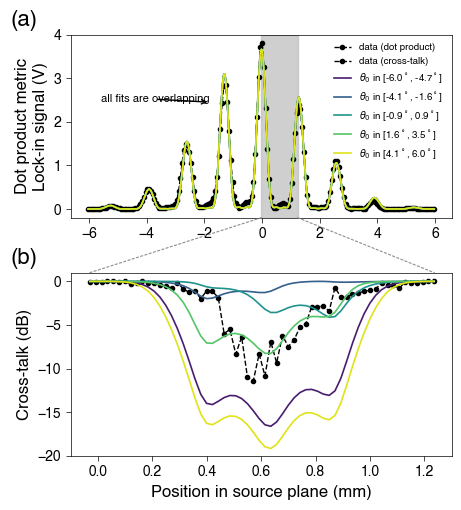

In [5]:
fig, (ax_dot, ax_cross) = plt.subplots(2, 1, figsize=(4.88, 4.84), gridspec_kw={"hspace": 0.30})
colors = plt.cm.viridis(np.linspace(0.08, 0.95, len(branches)))
x_fit = np.linspace(x_measured.min(), x_measured.max(), 1000)

ax_dot.plot(x_measured, y_measured, "o--", color="black", markersize=3, linewidth=1, label="data (dot product)")
ax_cross.plot(x_data, 10*np.log10(np.maximum(cross_talk_data, 1e-300)), "o--", color="black", markersize=3, linewidth=1, label="data (cross-talk)")

branch_handles = []
for color, row in zip(colors, branches.itertuples()):
    parameters = np.array([row.angle0, row.scale, row.focal, row.x_reference, row.w_gc])
    label = rf"$\theta_0$ in [{row.initial_min:.1f}$^\circ$, {row.initial_max:.1f}$^\circ$]"
    branch_handles.append(ax_dot.plot(x_fit, dot_model(x_fit, *parameters), color=color, linewidth=1.2, label=label)[0])
    ax_cross.plot(x_data, 10*np.log10(np.maximum(modeled_cross_talk(x_data, parameters), 1e-300)), color=color, linewidth=1.2)

zoom_min, zoom_max = x_data.min(), x_data.max()
ax_dot.axvspan(zoom_min, zoom_max, color="0.75", alpha=0.75, zorder=-1)
ax_dot.annotate("all fits are overlapping", xy=(-1.8, 2.45), xytext=(-5.6, 2.45), arrowprops={"arrowstyle": "->"}, fontsize=8)
ax_dot.set(xlabel="", ylabel="Dot product metric\nLock-in signal (V)", ylim=(-0.2, 4.0))
ax_cross.set(xlabel="Position in source plane (mm)", ylabel="Cross-talk (dB)", ylim=(-20, 1), xlim=(-0.1, 1.3))

handles = [ax_dot.lines[0], ax_cross.lines[0], *branch_handles]
labels = [handle.get_label() for handle in handles]
ax_dot.legend(handles, labels, loc="upper right", fontsize=7, handlelength=1.8)
for x in (zoom_min, zoom_max):
    fig.add_artist(ConnectionPatch(
        xyA=(x, ax_dot.get_ylim()[0]), coordsA=ax_dot.transData,
        xyB=(x, ax_cross.get_ylim()[1]), coordsB=ax_cross.transData,
        color="0.55", linestyle=(0, (2, 2)), linewidth=0.8,
    ))
ax_dot.text(-0.16, 1.02, "(a)", transform=ax_dot.transAxes, fontsize=16, va="bottom")
ax_cross.text(-0.16, 1.02, "(b)", transform=ax_cross.transAxes, fontsize=16, va="bottom")
fig.subplots_adjust(left=0.20, right=0.98, bottom=0.11, top=0.98)
save_figure(fig, "si_figure4_multistart_sensitivity")
plt.show()